<a href="https://colab.research.google.com/github/riteshkrkumarweb/Learning_AI/blob/main/PCA_on_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [1]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

NameError: name 'pd' is not defined

In [ ]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
29864,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import matplotlib.pyplot as plt

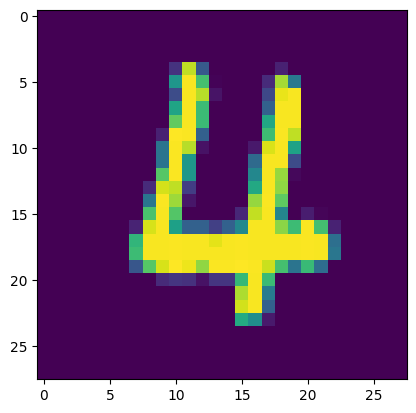

In [ ]:
plt.imshow(df.iloc[4209,1:].values.reshape(28,28))

In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
from sklearn.model_selection import train_test_split

# Split features (X) and target (y) into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # Ensures reproducible results
)

In [ ]:
X_train.shape

(33600, 784)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

10.549545049667358


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9648809523809524


In [ ]:
#Mean Centering via StandardScaler ,FeatureScaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
#Mean Centring via Standard Scaler , Feature Scaling
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=100)

In [ ]:

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [ ]:
X_train_trf.shape

(33600, 100)

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
#we train the data again but when we transform the shape 784D to 100D
knn.fit(X_train_trf ,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred)
#Here we saw that when we 784Dimesion our accuracy_score is 96% but when we applied the
#PCA and rededuce the dimesion to the 100D our accuracy_score is same or there is small differenece
print(accuracy_score(y_test,y_pred))

0.9717857142857143


In [ ]:
#Here we Create a loop for the PCA that first he take 1Dthen2Dthen3mainColumns
for i in range(1,784):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf ,y_train)

    y_pred = knn.predict(X_test_trf)
    accu = accuracy_score(y_test,y_pred)
    print(f'Number of components {i} Accuracy Score {accu*100}%')


Number of components 1 Accuracy Score 27.30952380952381%
Number of components 2 Accuracy Score 42.214285714285715%
Number of components 3 Accuracy Score 48.488095238095234%
Number of components 4 Accuracy Score 61.94047619047619%
Number of components 5 Accuracy Score 72.97619047619047%
Number of components 6 Accuracy Score 81.88095238095238%
Number of components 7 Accuracy Score 86.69047619047619%
Number of components 8 Accuracy Score 89.38095238095238%
Number of components 9 Accuracy Score 90.75%
Number of components 10 Accuracy Score 92.47619047619048%
Number of components 11 Accuracy Score 93.15476190476191%
Number of components 12 Accuracy Score 94.21428571428572%
Number of components 13 Accuracy Score 94.92857142857143%
Number of components 14 Accuracy Score 95.4047619047619%
Number of components 15 Accuracy Score 95.44047619047619%
Number of components 16 Accuracy Score 95.83333333333334%
Number of components 17 Accuracy Score 96.16666666666667%
Number of components 18 Accuracy S

KeyboardInterrupt: 

In [ ]:
#Automatically Automatically selects best number of features
def PCAresult():
    pca = PCA(n_components=0.95) # keep 95% variance
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf ,y_train)

    y_pred = knn.predict(X_test_trf)
    print(accuracy_score(y_test,y_pred))


PCAresult()

0.9671428571428572
